<a href="https://colab.research.google.com/github/OutisAyo/council-classifier-/blob/main/notebooks/05_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Automated Classification and Prioritisation of Local Council Service Requests in the UK
## Notebook 05 — Random Forest Classifier (Department Prediction)

**Author:** Fashina Fuad Ayomide  
**MSc Data Science, University of South Wales**

This notebook builds a Random Forest classifier to predict the assigned department from the request text, and compares it against Naive Bayes and Logistic Regression baselines.

## Mounting Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the processed data


In [3]:
processed_dir = '/content/drive/MyDrive/council-classifier/processed'

X_train = np.load(f'{processed_dir}/X_train.npy', allow_pickle=True)
X_test = np.load(f'{processed_dir}/X_test.npy', allow_pickle=True)
y_dept_train = np.load(f'{processed_dir}/y_dept_train.npy', allow_pickle=True)
y_dept_test = np.load(f'{processed_dir}/y_dept_test.npy', allow_pickle=True)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 203501
Test set size: 50876


## Converting text to numerical features using Bag of Words

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=1500)
X_train_vec = cv.fit_transform(X_train).toarray()
X_test_vec = cv.transform(X_test).toarray()

print("Training matrix shape:", X_train_vec.shape)
print("Test matrix shape:", X_test_vec.shape)

Training matrix shape: (203501, 579)
Test matrix shape: (50876, 579)


## Training the Random Forest model on the Training set

Random Forest builds many decision trees on random subsets of the data and features, then combines their votes. Unlike Naive Bayes and Logistic Regression, it can capture non-linear patterns and feature interactions.

In [5]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
classifier.fit(X_train_vec, y_dept_train)

RandomForestClassifier(n_jobs=-1, random_state=0)

## Predicting the Test set results

In [6]:
y_pred = classifier.predict(X_test_vec)

print("Sample predictions vs actual:")
comparison = pd.DataFrame({'Predicted': y_pred[:15], 'Actual': y_dept_test[:15]})
print(comparison)

Sample predictions vs actual:
                   Predicted                    Actual
0           Waste Management          Waste Management
1         Pollution Division        Pollution Division
2           Waste Management          Waste Management
3         Pollution Division        Pollution Division
4           Waste Management          Waste Management
5   Food and Safety Division  Food and Safety Division
6           Waste Management          Waste Management
7           Waste Management          Waste Management
8         Licensing Division        Licensing Division
9           Waste Management          Waste Management
10          Waste Management          Waste Management
11          Waste Management          Waste Management
12        Pollution Division        Pollution Division
13          Waste Management          Waste Management
14          Waste Management          Waste Management


## Making the Confusion Matrix

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cm = confusion_matrix(y_dept_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(y_dept_test, y_pred))

Confusion Matrix:
[[ 1180     0     3     0     0     0]
 [    1  2094     1     3     0     4]
 [    0     0  1600     2     3     0]
 [    0     5     0  6393     0     6]
 [    2     1     1     4   175     1]
 [    0     1     1    29     0 39366]]

Accuracy: 0.9986634169352937


## Classification Report

In [8]:
print(classification_report(y_dept_test, y_pred))

                            precision    recall  f1-score   support

  Food and Safety Division       1.00      1.00      1.00      1183
          Housing Division       1.00      1.00      1.00      2103
        Licensing Division       1.00      1.00      1.00      1605
        Pollution Division       0.99      1.00      1.00      6404
Trading Standards Division       0.98      0.95      0.97       184
          Waste Management       1.00      1.00      1.00     39397

                  accuracy                           1.00     50876
                 macro avg       0.99      0.99      0.99     50876
              weighted avg       1.00      1.00      1.00     50876



## Visualising the Confusion Matrix

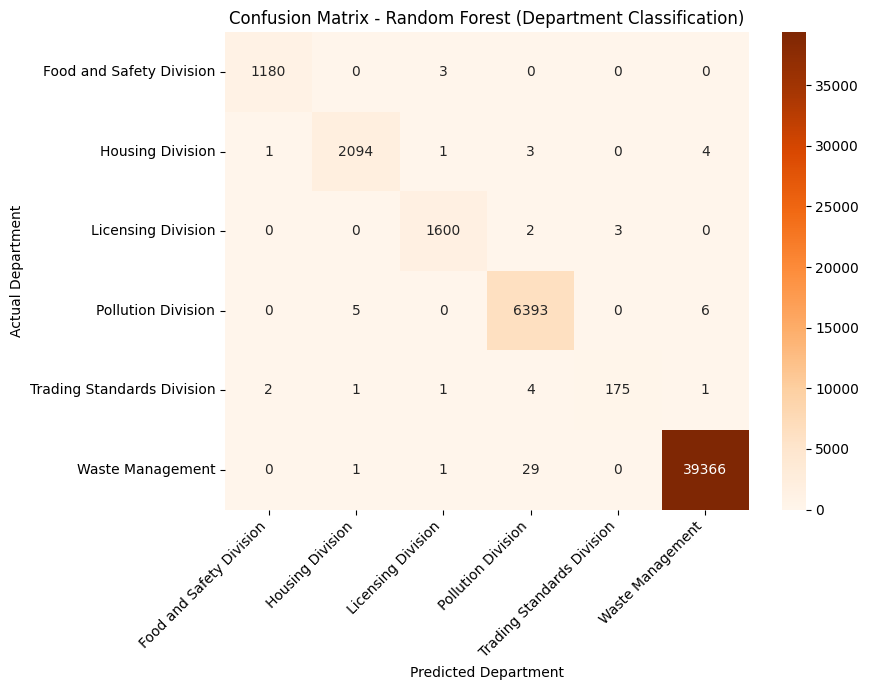

In [9]:
plt.figure(figsize=(9, 7))
unique_labels = sorted(set(y_dept_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix - Random Forest (Department Classification)')
plt.xlabel('Predicted Department')
plt.ylabel('Actual Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Feature importance

Unlike Naive Bayes or Logistic Regression, Random Forest can directly tell us which words were most useful in making decisions across all trees.

In [10]:
importances = classifier.feature_importances_
feature_names = cv.get_feature_names_out()

importance_df = pd.DataFrame({
    'word': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 20 most important words:")
print(importance_df.head(20))

Top 20 most important words:
           word  importance
385   pollution    0.093160
376        pest    0.085654
136     control    0.071843
409        rats    0.045799
246         hmo    0.030604
413   recycling    0.028257
435     request    0.021503
167    domestic    0.020887
216        food    0.020015
340         non    0.019485
232     general    0.018309
551     vehicle    0.018195
124  collection    0.017940
18       advice    0.017656
56        badge    0.014024
214  flytipping    0.013949
505      street    0.013567
86     business    0.013333
32       animal    0.012752
458       scene    0.012537


## Appending results to the comparison file

In [12]:
from sklearn.metrics import f1_score

results_path = '/content/drive/MyDrive/council-classifier/processed/model_results.csv'
results_df = pd.read_csv(results_path)

new_result = {
    'model': 'Random Forest',
    'accuracy': accuracy_score(y_dept_test, y_pred),
    'f1_macro': f1_score(y_dept_test, y_pred, average='macro'),
    'f1_weighted': f1_score(y_dept_test, y_pred, average='weighted')
}

results_df = pd.concat([results_df, pd.DataFrame([new_result])], ignore_index=True)
results_df.to_csv(results_path, index=False)

print(results_df)

                 model  accuracy  f1_macro  f1_weighted
0          Naive Bayes  0.997956  0.979528     0.997955
1  Logistic Regression  0.998585  0.991498     0.998584
2        Random Forest  0.998663  0.992122     0.998662
